In [48]:
# bibliotecas
import warnings
warnings.filterwarnings("ignore")
from yfinance import download
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Ellipse
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

---

# **1.0**

*Dados*

In [49]:
# Parametros
interval = "1d"
ticker = "klbn4.sa"
period = "10y"

In [50]:
# Download dos dados
df = download(
    tickers=ticker, 
    period=period, 
    interval=interval, 
    auto_adjust=False, 
    progress=False
    )
df = df.droplevel(1, axis=1)
df.tail(24)

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2025-12-03,3.423352,3.594059,3.594059,3.524752,3.554455,4364715
2025-12-04,3.461075,3.633663,3.633663,3.584158,3.603960,3837495
2025-12-05,3.517659,3.693069,3.732673,3.633663,3.633663,6765889
2025-12-08,3.545951,3.722772,3.732673,3.653465,3.702970,2867390
2025-12-09,3.564813,3.742574,3.851485,3.722772,3.762376,8475920
2025-12-10,3.640259,3.821782,3.821782,3.732673,3.762376,3627516
2025-12-11,3.555382,3.732673,3.841584,3.722772,3.821782,5835477
2025-12-12,3.555382,3.732673,3.762376,3.693069,3.752475,4138071
2025-12-15,3.621397,3.801980,3.821782,3.702970,3.742574,5777705


In [51]:
print(f'Quantidade de dados: {len(df)}')

Quantidade de dados: 2492


---

# **2.0**

*Funções*

In [52]:
def media_acumulada(df_values):
    lista = []
    value = 0
    for i, v in enumerate(df_values):
        value += v
        lista.append(value / i)
    return lista

def estocastico(df, n=8):
    lowest_low = df['Low'].rolling(n).min()
    highest_high = df['High'].rolling(n).max()

    df['K'] = 100 * (df['Close'] - lowest_low) / (highest_high - lowest_low)
    df['D'] = df['K'].rolling(3).mean()  # linha lenta
    return df

def retorno_mensal_ano(df):
    tabela = (
        df.groupby(["ano", "mes"])[["retorno"]]
        .sum()
        .reset_index()
        .pivot(index="ano", columns="mes", values="retorno")
    )
    return tabela

def encontrar_topos_fundos(series):
    topos = []
    fundos = []
    for row in range(1, len(series)-1):
        if series[row] < series[row-1] and series[row-1] > series[row-2]:
            topos.append(row-1)

        elif series[row] > series[row-1] and series[row-1] < series[row-2]:
            fundos.append(row-1)
            
    return topos, fundos 

def regressao_linear(x, y):
    x = np.arange(x)
    y = y
    coef = np.polyfit(x, y, 1)
    return coef[0] * x + coef[1]

---

# **3.0**

*Adicionando funções*

In [53]:
# Calculo do retorno do fechamento
# pct_change = (valor_atual - valor_anterior) / valor_anterior
df['retorno'] = df['Close'].pct_change(1)

# Desvio padrão 21 dias dos retornos
df['sd'] = df['retorno'].rolling(21).std()

In [54]:
# Dados perdidos no calculo do retorno e do desvio padrão
df.iloc[:, 6:].isnull().sum()

Price
retorno     1
sd         21
dtype: int64

In [55]:
# Removendo dados faltatens no calculo do retorno e do desvio padrão
df.dropna(inplace=True)

df.iloc[:, 6:].tail(3)

Price,retorno,sd
Date,,
2026-01-07,-0.010753,0.016928
2026-01-08,0.000000,0.016780
2026-01-09,0.005435,0.016438


In [56]:
# Adicionando a função da média acumulada de todo o período
df['media_acumulada_Close'] = media_acumulada(df['Close'].values)
df['media_acumulada_sd'] = media_acumulada(df['sd'].values)
df.iloc[:, 8:].tail(3)

Price,media_acumulada_Close,media_acumulada_sd
Date,,
2026-01-07,3.492516,0.016832
2026-01-08,3.492592,0.016832
2026-01-09,3.492675,0.016832


In [57]:
# Dados perdidos da função media acumulada
df.iloc[:, 8:].isnull().sum()

Price
media_acumulada_Close    0
media_acumulada_sd       0
dtype: int64

In [58]:
# Adicionando a função estocastico
df = estocastico(df)
df.iloc[:, 10:].tail(3)

Price,K,D
Date,,
2026-01-07,7.142857,26.825397
2026-01-08,27.777778,24.973545
2026-01-09,38.888889,24.603175


In [59]:
# Dados perdidos da função estocastico
df.iloc[:, 10:].isnull().sum()

Price
K    7
D    9
dtype: int64

In [60]:
# Adicionando colunas com meses e anos númericos
df['mes'] = df.index.month
df['ano'] = df.index.year

df.iloc[:, 12:].tail(3)

Price,mes,ano
Date,,
2026-01-07,1,2026
2026-01-08,1,2026
2026-01-09,1,2026


In [61]:
# Removendo dados faltatens do inicio do data frame
df.dropna(inplace=True)

df.tail(3)

Price,Adj Close,Close,High,Low,Open,Volume,retorno,sd,media_acumulada_Close,media_acumulada_sd,K,D,mes,ano
Date,,,,,,,,,,,,,,
2026-01-07,3.68,3.68,3.74,3.67,3.72,2826200,-0.010753,0.016928,3.492516,0.016832,7.142857,26.825397,1,2026
2026-01-08,3.68,3.68,3.71,3.63,3.68,2869300,0.000000,0.016780,3.492592,0.016832,27.777778,24.973545,1,2026
2026-01-09,3.70,3.70,3.71,3.68,3.68,255700,0.005435,0.016438,3.492675,0.016832,38.888889,24.603175,1,2026


In [62]:
# Adicionando médias
df['media_21_a_close'] = df['Close'].rolling(21).mean()

df['media_21_a_max_retorno'] = df['retorno'].rolling(21).max()
df['media_21_a_mean_retorno'] = df['retorno'].rolling(21).mean()
df['media_21_a_min_retorno'] = df['retorno'].rolling(21).min()

In [63]:
# Adicionando regressões lineares
df['regressao_linear_close'] = regressao_linear(x=len(df), y=df['Close'].values)
df['regressao_linear_sd'] = regressao_linear(x=len(df), y=df['sd'])
df['regressao_linear_retorno'] = regressao_linear(x=len(df), y=df['retorno'])

In [64]:
df['diferenca_regressao_linear_e_close'] = df["Close"] - df['regressao_linear_close']

In [65]:
df.iloc[:, 14:].tail(3)

Price,media_21_a_close,media_21_a_max_retorno,media_21_a_mean_retorno,media_21_a_min_retorno,regressao_linear_close,regressao_linear_sd,regressao_linear_retorno,diferenca_regressao_linear_e_close
Date,,,,,,,,
2026-01-07,3.724677,0.023686,0.001264,-0.041667,4.386354,0.013768,0.000136,-0.706354
2026-01-08,3.726883,0.023686,0.000739,-0.041667,4.387081,0.013766,0.000136,-0.707081
2026-01-09,3.727213,0.023686,0.000219,-0.041667,4.387809,0.013763,0.000136,-0.687808


In [66]:
df.columns

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'retorno', 'sd',
       'media_acumulada_Close', 'media_acumulada_sd', 'K', 'D', 'mes', 'ano',
       'media_21_a_close', 'media_21_a_max_retorno', 'media_21_a_mean_retorno',
       'media_21_a_min_retorno', 'regressao_linear_close',
       'regressao_linear_sd', 'regressao_linear_retorno',
       'diferenca_regressao_linear_e_close'],
      dtype='object', name='Price')

***

# **4.0**

*Retornos, Distribuição, Desvio Padrão*

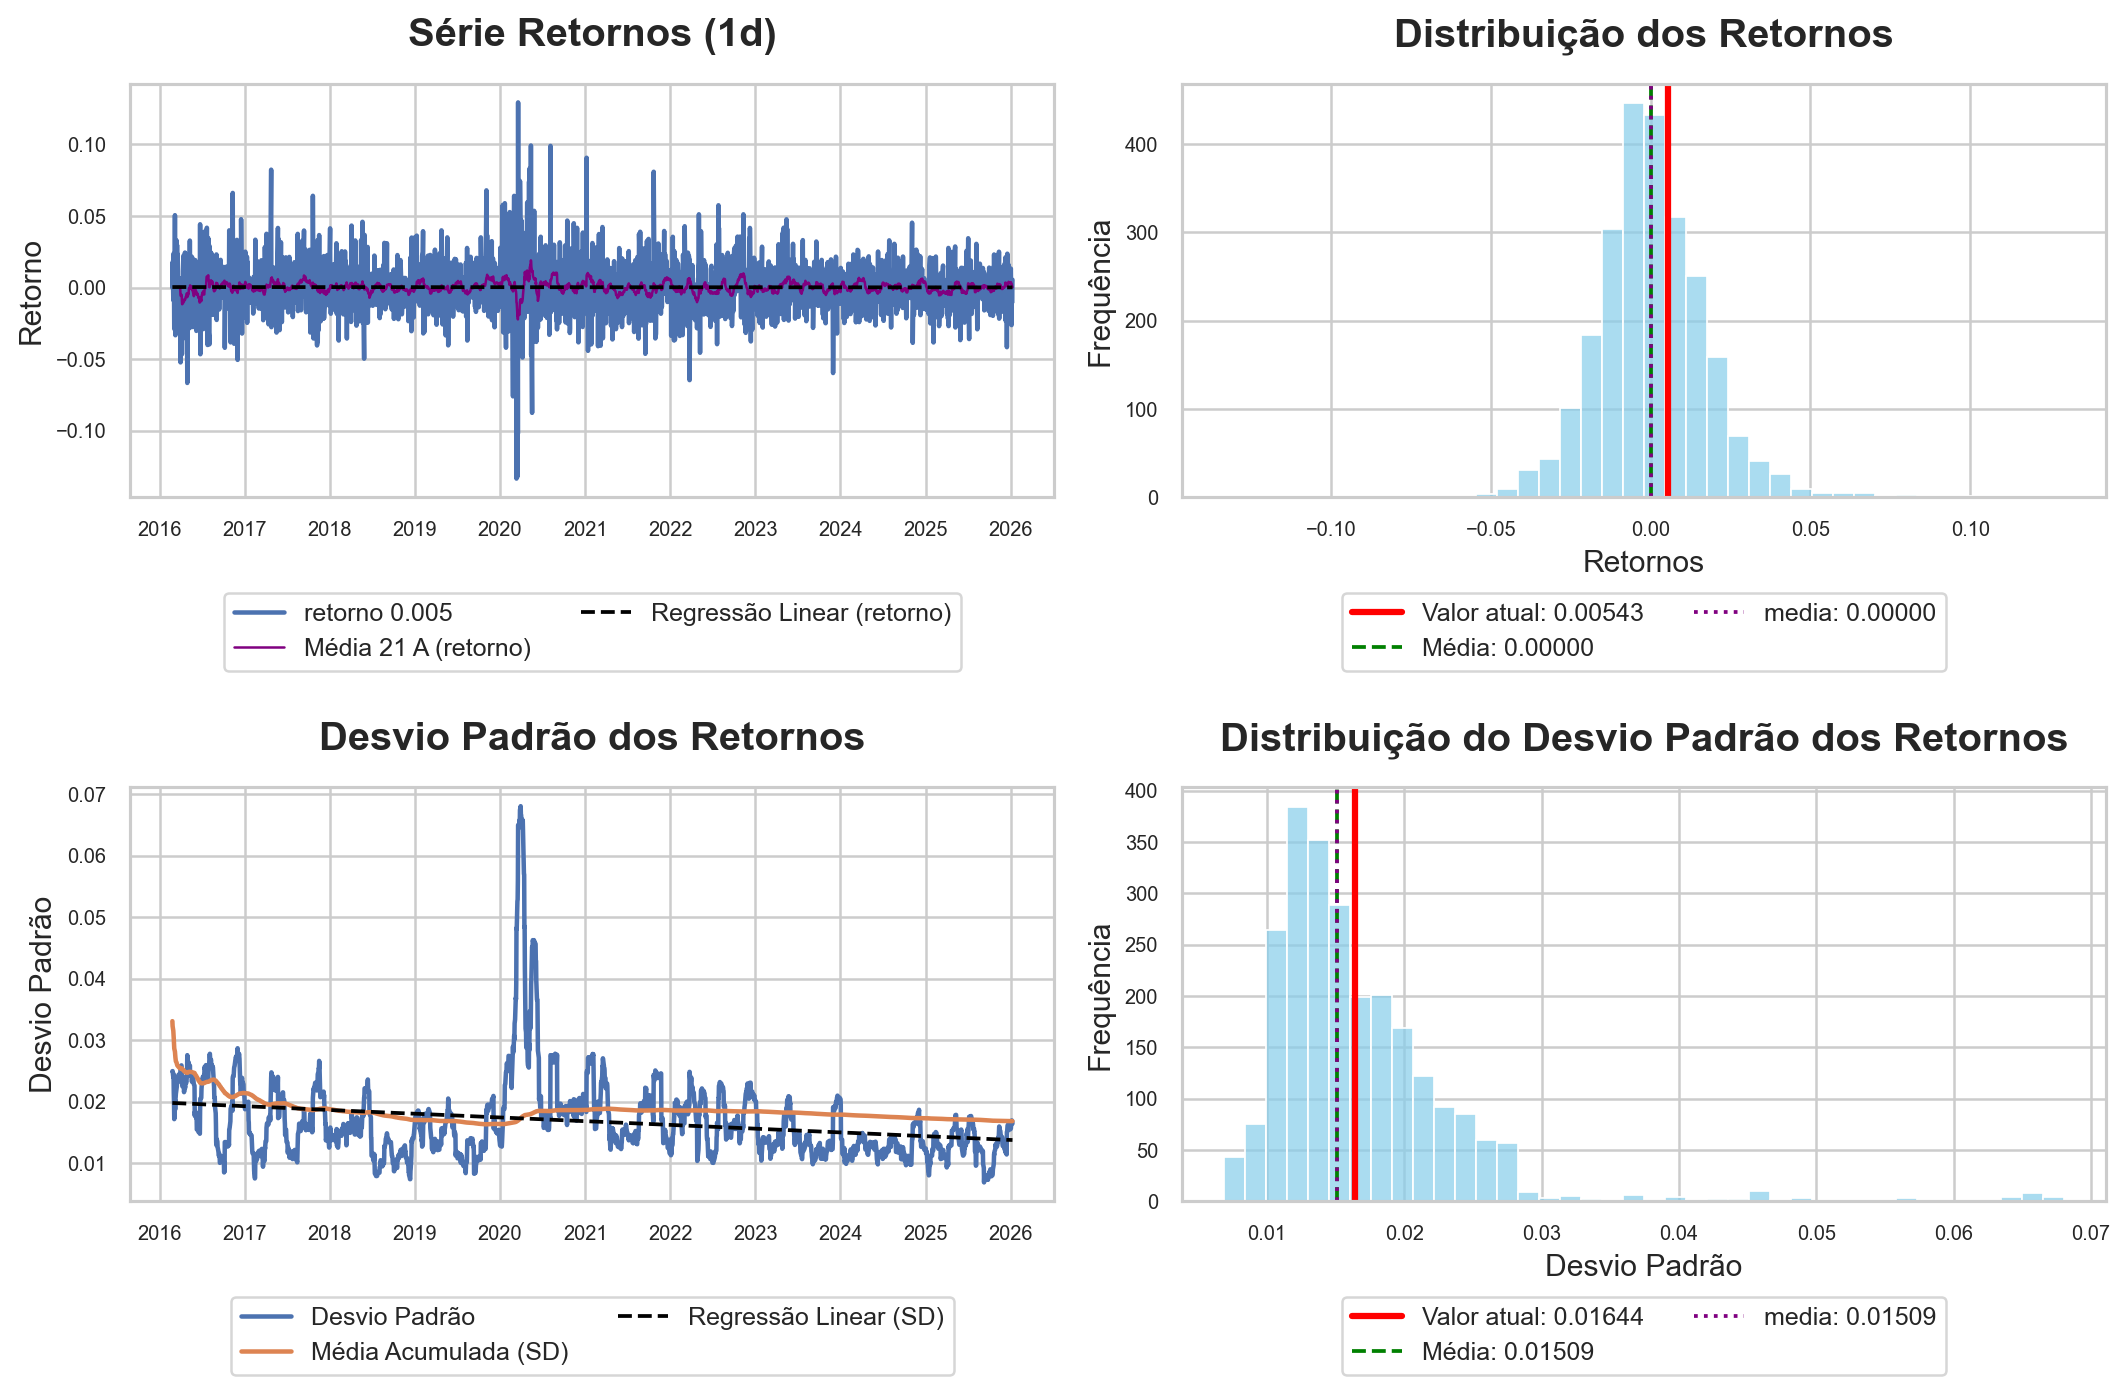

In [67]:
sns.set_theme(style="whitegrid")  
plt.rcParams["figure.dpi"] = 180

# Figura com quatro gráficos
fig, ax = plt.subplots(
    2, 2,
    figsize=(12, 8),
    sharex=False,
    sharey=False
)

ax1 = ax[0,0]
ax2 = ax[1,0]
ax3 = ax[0,1]
ax4 = ax[1,1]

# opcional: esconder o último eixo vazio
# ax[0,1].set_visible(False)

# --- Gráfico 1: Série histórica + Média Acumulada ---

valor_atual = df['retorno'].iloc[-1]
sns.lineplot(
    ax=ax1,
    x=df.index,
    y=df["retorno"],
    linewidth=1.8,
    label=f"retorno {valor_atual :.3f}"
)

sns.lineplot(
    ax=ax1,
    x=df.index,
    y=df["media_21_a_mean_retorno"],
    linewidth=1.0,
    label="Média 21 A (retorno)",
    color="purple"
)

sns.lineplot(
    ax=ax1,
    x=df.index,
    y=df["regressao_linear_retorno"],
    color="black", 
    linewidth=1.5, 
    linestyle="--",
    label="Regressão Linear (retorno)"
)


ax1.set_title(f"Série Retornos ({interval})", fontsize=16, weight="bold", pad=15)
ax1.set_xlabel(None)
ax1.set_ylabel("Retorno")
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.20), ncol=2, fontsize=10)

# --- Gráfico 2: Desvio  Padrão + Média Acumulada ---

sns.lineplot(
    ax=ax2,
    x=df.index,
    y=df["sd"],
    linewidth=1.8,
    label="Desvio Padrão"
)

sns.lineplot(
    ax=ax2,
    x=df.index,
    y=df["media_acumulada_sd"],
    linewidth=1.8,
    label="Média Acumulada (SD)"
)

sns.lineplot(
    ax=ax2,
    x=df.index, 
    y=df['regressao_linear_sd'], 
    color="black", 
    linewidth=1.5, 
    linestyle="--",
    label="Regressão Linear (SD)"
)

ax2.set_title("Desvio Padrão dos Retornos", fontsize=16, weight="bold", pad=15)
ax2.set_xlabel(None)
ax2.set_ylabel("Desvio Padrão")
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.20), ncol=2, fontsize=10)

# --- Gráfico 3: Distribuição dos Retornos ---

df_retorno = df["retorno"]
valor_atual = df_retorno.iloc[-1]
media = df_retorno.mean()
media = df_retorno.median()

sns.histplot(
    ax=ax3,
    data=df_retorno,
    bins=40,
    color="skyblue",
    alpha=0.7
)

# Indicador do Valor atual
ax3.axvline(valor_atual, color="red", linewidth=2.5,
            label=f"Valor atual: {valor_atual:.5f}")

# Opção: média e media
ax3.axvline(media, color="green", linestyle="--", label=f"Média: {media:.5f}")
ax3.axvline(media, color="purple", linestyle=":", label=f"media: {media:.5f}")

ax3.set_title("Distribuição dos Retornos", fontsize=16, weight="bold", pad=15)
ax3.set_xlabel("Retornos")
ax3.set_ylabel("Frequência")
ax3.legend(loc='upper center', bbox_to_anchor=(0.5, -0.20), ncol=2, fontsize=10)

# --- Gráfico 4: Distribuição do Desvio Padrão dos Retornos ---

df_desvio_padrao = df["sd"]
valor_atual = df_desvio_padrao.iloc[-1]
media = df_desvio_padrao.mean()
media = df_desvio_padrao.median()

sns.histplot(
    ax=ax4,
    data=df_desvio_padrao,
    bins=40,
    color="skyblue",
    alpha=0.7
)

# Indicador do Valor atual
ax4.axvline(valor_atual, color="red", linewidth=2.5,
            label=f"Valor atual: {valor_atual:.5f}")

# Opção: média e media
ax4.axvline(media, color="green", linestyle="--", label=f"Média: {media:.5f}")
ax4.axvline(media, color="purple", linestyle=":", label=f"media: {media:.5f}")

ax4.set_title("Distribuição do Desvio Padrão dos Retornos", fontsize=16, weight="bold", pad=15)
ax4.set_xlabel("Desvio Padrão")
ax4.set_ylabel("Frequência")
ax4.legend(loc='upper center', bbox_to_anchor=(0.5, -0.20), ncol=2, fontsize=10)

for a in [ax1, ax2, ax3, ax4]:
    a.tick_params(axis='both', labelsize=8)  # tamanho dos números dos eixos
    
plt.tight_layout()
plt.show()


In [68]:
# Estatísticas
sd_mean = df['sd'].mean()
sd_p75  = df['sd'].quantile(0.75)
sd_p90  = df['sd'].quantile(0.90)

# Subplots
fig = make_subplots(
    rows=3,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.05,
    row_heights=[0.65, 0.35, 0.35],
    subplot_titles=("Preço do Ativo", "Volatilidade (SD 21 dias)")
)

# preço 
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df['Close'],
        name='Close',
        line=dict(width=2)
    ),
    row=1, col=1
)

# sd
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df['sd'],
        name='SD 21d',
        line=dict(color='black')
    ),
    row=2, col=1
)

fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df['retorno'],
        name='retorno',
        line=dict(color='black')
    ),
    row=3, col=1
)

# Linhas horizontais SD
fig.add_hline(y=sd_mean, row=2, line_dash="dot",
              line_color="blue", annotation_text="Média")

fig.add_hline(y=sd_p75, row=2, line_dash="dash",
              line_color="orange", annotation_text="P75")

fig.add_hline(y=sd_p90, row=2, line_dash="dash",
              line_color="red", annotation_text="P90")

# Layout
fig.update_layout(
    template="plotly_white",
    hovermode="x unified",
    height=700,
    legend=dict(orientation="h", y=1.05, x=0.1, xanchor="center")
)

fig.show()


---

# **5.0**

*Relação entre Retorno e Desvio Padrão*



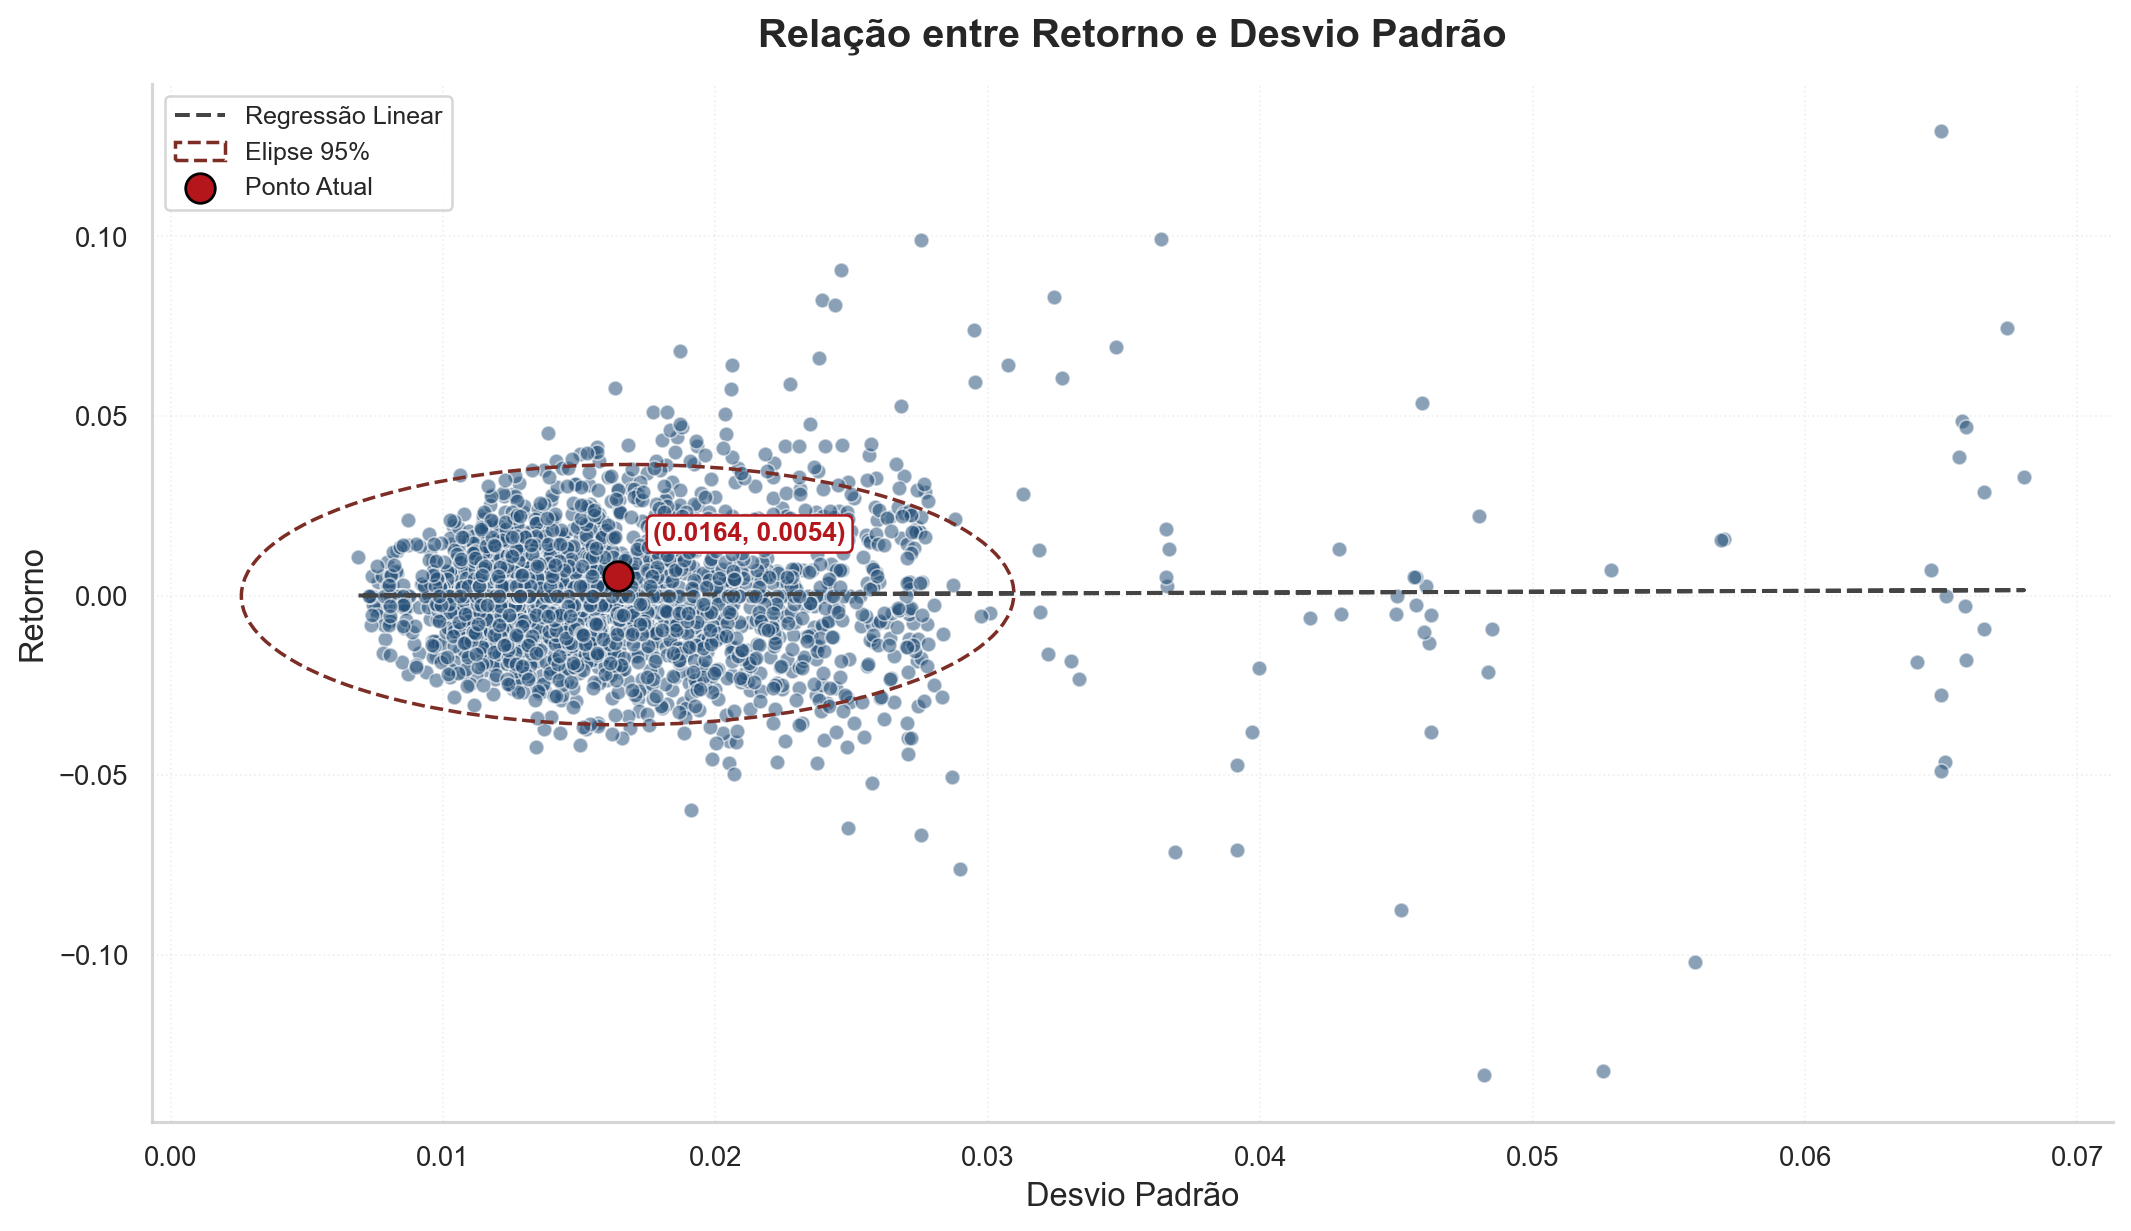

In [69]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 180
plt.figure(figsize=(12, 7))

x = df["sd"]
y = df["retorno"]

# --- Gráfico: Dispersão ---
plt.scatter(
    x, y,
    alpha=0.55,
    color="#28527A",          
    edgecolor="white",
    linewidth=0.7
)

# Regressão linear
coef = np.polyfit(x, y, 1)
poly = np.poly1d(coef)

plt.plot(
    x, poly(x),
    color="#444444",
    linestyle="--",
    linewidth=1.6,
    label="Regressão Linear"
)

# Elipse de confiança 95%
cov = np.cov(x, y)
lambda_, v = np.linalg.eig(cov)
lambda_ = np.sqrt(lambda_)

ell = Ellipse(
    xy=(np.mean(x), np.mean(y)),
    width=lambda_[0] * 4,
    height=lambda_[1] * 4,
    angle=np.rad2deg(np.arccos(v[0, 0])),
    edgecolor="#7B2D26",        
    facecolor="none",
    linewidth=1.4,
    linestyle="--",
    label="Elipse 95%"
)
plt.gca().add_patch(ell)

# Ponto atual
sd_atual = x.iloc[-1]
ret_atual = y.iloc[-1]

plt.scatter(
    sd_atual, ret_atual,
    color="#B4161B",           
    s=140,
    edgecolor="black",
    linewidth=1.1,
    zorder=5,
    label="Ponto Atual"
)

plt.annotate(
    f"({sd_atual:.4f}, {ret_atual:.4f})",
    xy=(sd_atual, ret_atual),
    xytext=(14, 14),
    textcoords="offset points",
    fontsize=10.5,
    weight="bold",
    color="#B4161B",
    bbox=dict(
        boxstyle="round,pad=0.25",
        fc="white", ec="#B4161B", lw=1
    )
)

# Layout e eixos
plt.title("Relação entre Retorno e Desvio Padrão", fontsize=16, weight="bold", pad=15)
plt.xlabel("Desvio Padrão", fontsize=13)
plt.ylabel("Retorno", fontsize=13)
plt.grid(True, linestyle=":", linewidth=0.7, alpha=0.30)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_alpha(0.80)
ax.spines["bottom"].set_alpha(0.80)

plt.legend(frameon=True, fontsize=10)

plt.tight_layout()
plt.show()

---

# **6.0**

*Preços, Série Histórica, Regressão Linear, Média Acumulada, Estocástico AT*

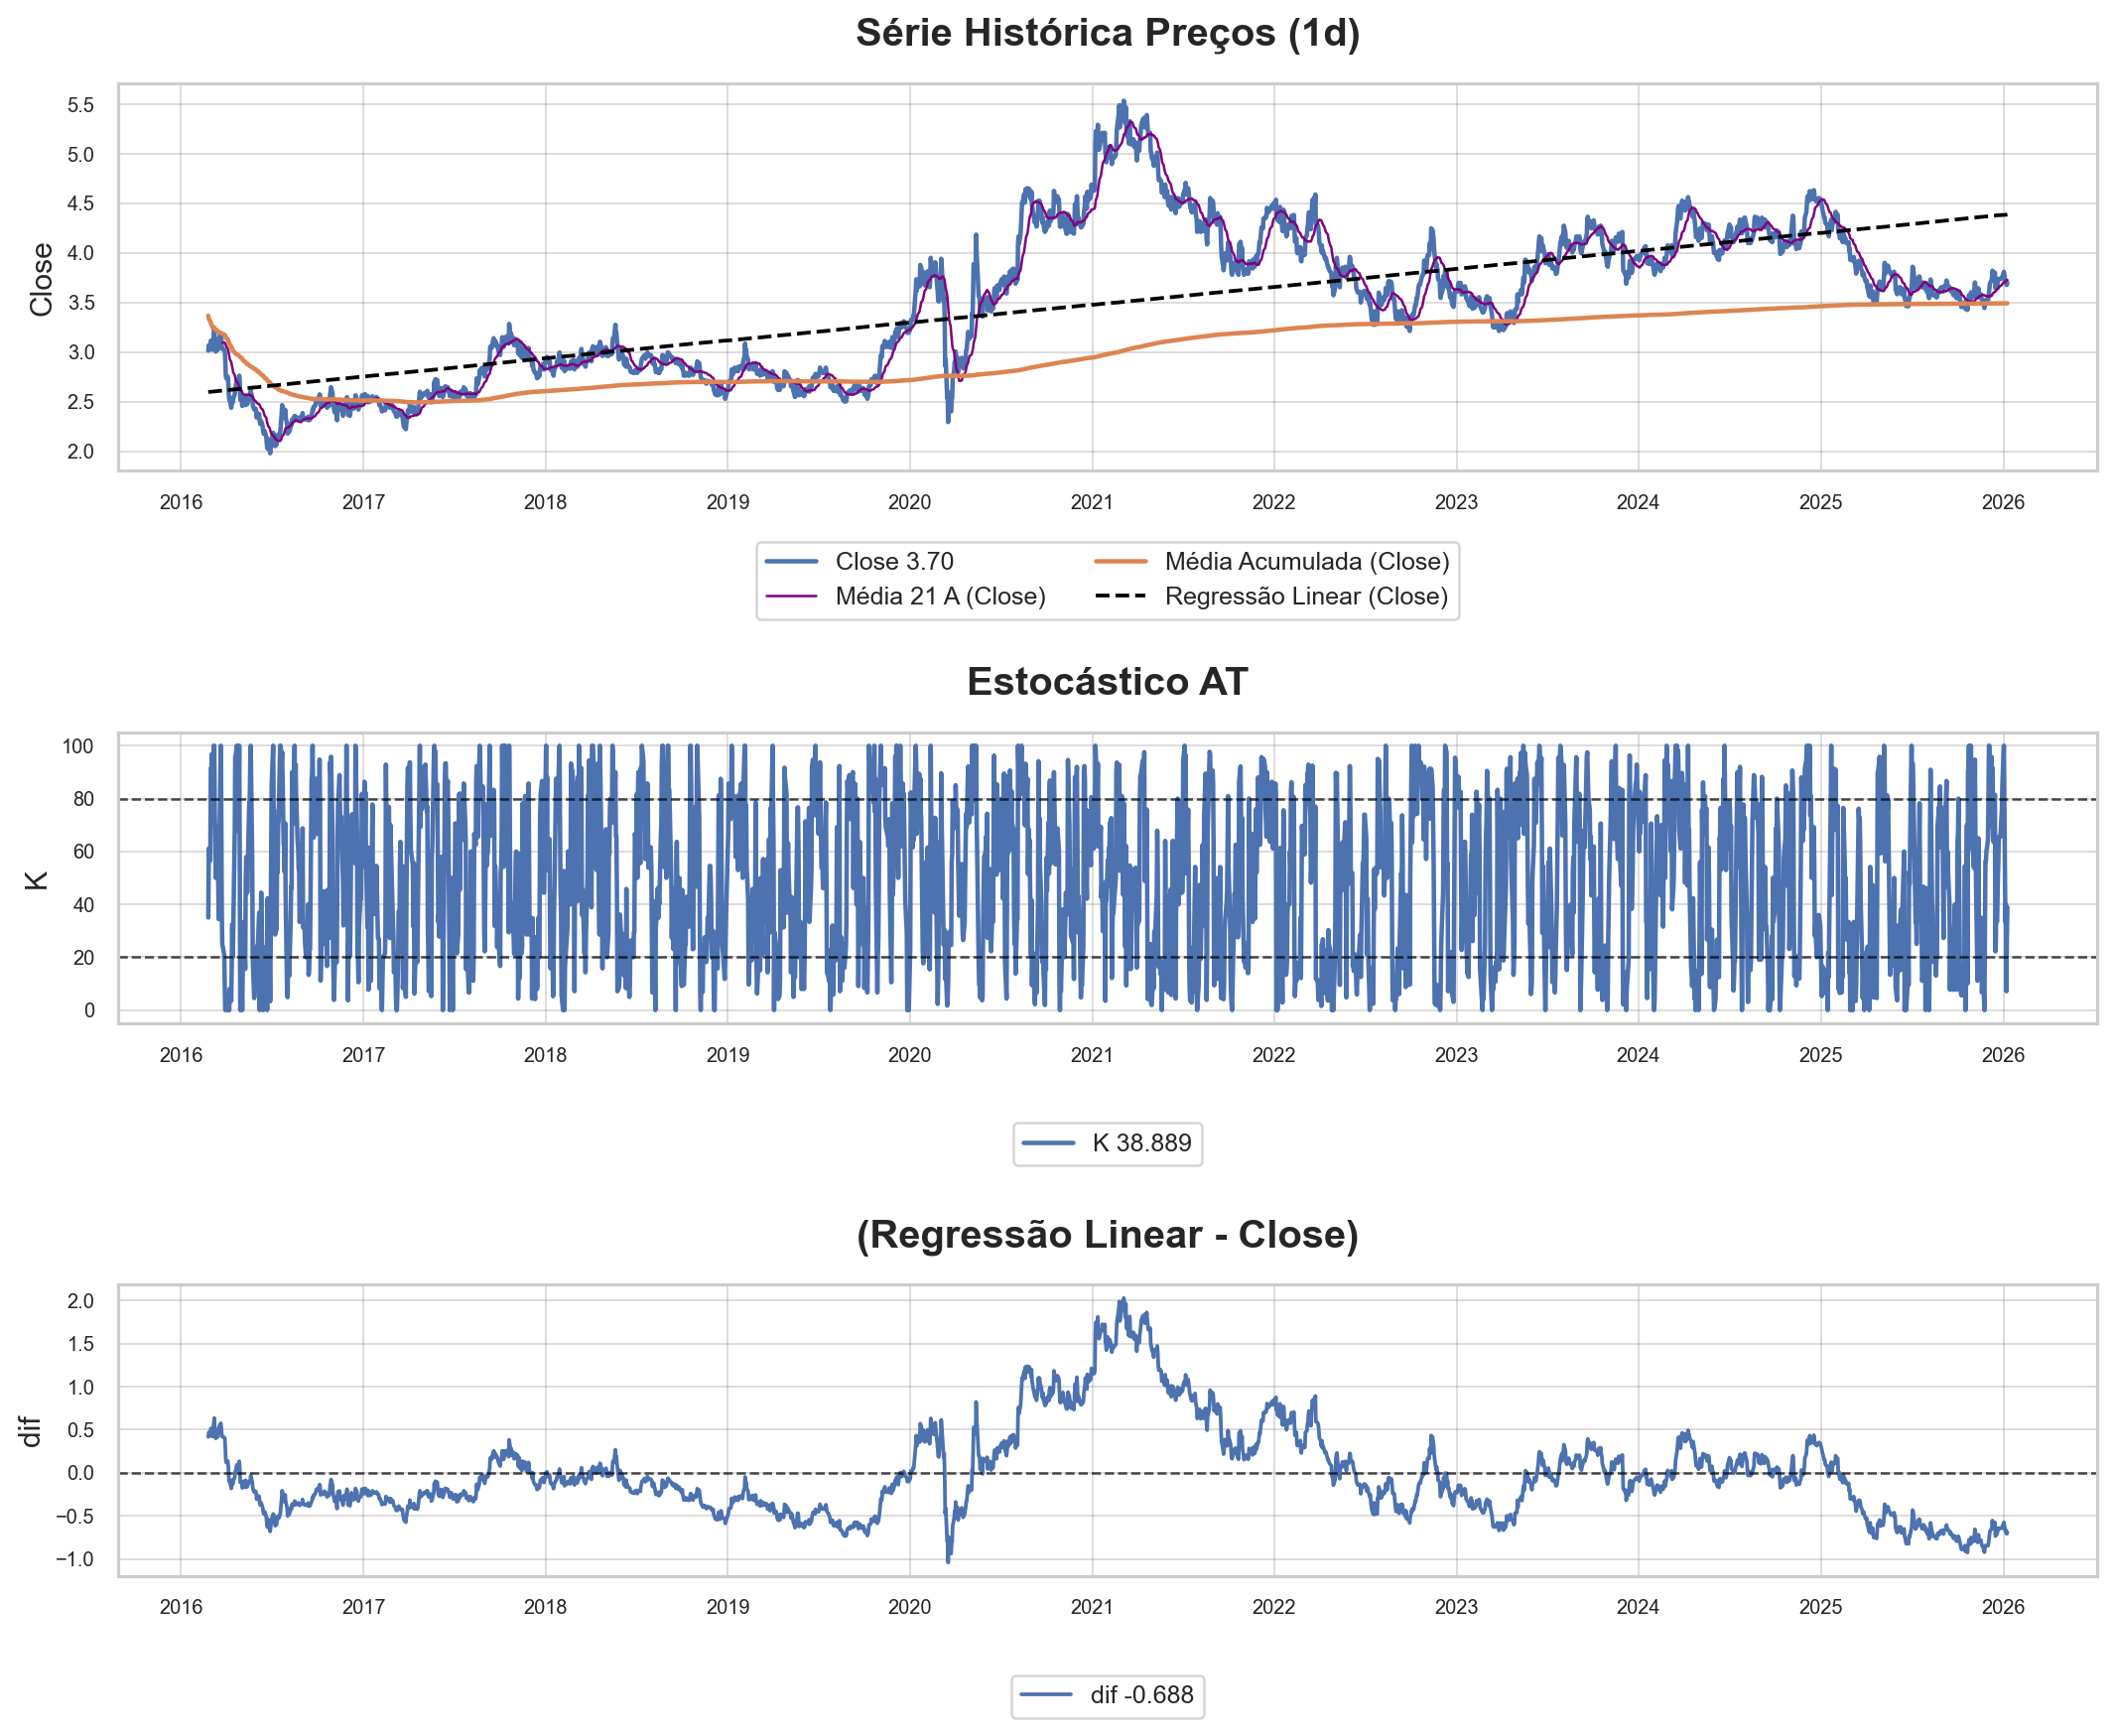

In [70]:
sns.set_theme(style="whitegrid") # Estilo seaborn 
plt.rcParams["figure.dpi"] = 180 # Aumenta a qualidade da imagem

# Figura com quatro gráficos
fig, ax = plt.subplots(
    3, 1,
    figsize=(12, 10),
    sharex=False,
    sharey=False,
    gridspec_kw={"height_ratios": [2, 1.5,  1.5]}
)

ax1 = ax[0]
ax2 = ax[1]
ax3 = ax[2]

# --- Gráfico 1: Série histórica + Média Acumulada ---

valor_atual = df["Close"].iloc[-1]
sns.lineplot(
    ax=ax1,
    x=df.index,
    y=df["Close"],
    linewidth=1.8,
    label=f"Close {valor_atual:.2f}"
)

sns.lineplot(
    ax=ax1,
    x=df.index,
    y=df["media_21_a_close"],
    linewidth=1.0,
    label="Média 21 A (Close)",
    color="purple"
)

sns.lineplot(
    ax=ax1,
    x=df.index,
    y=df["media_acumulada_Close"],
    linewidth=1.8,
    label="Média Acumulada (Close)"
)

sns.lineplot(
    ax=ax1,
    x=df.index, 
    y=df['regressao_linear_close'], 
    color="black", 
    linewidth=1.5, 
    linestyle="--",
    label="Regressão Linear (Close)"
)


ax1.set_title(f"Série Histórica Preços ({interval})", fontsize=16, weight="bold", pad=15)
ax1.set_ylabel("Close")
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=10)

# --- Gráfico 2: Estocástico K ---

valor_atual = df["K"].iloc[-1]
sns.lineplot(
    ax=ax2,
    x=df.index,
    y=df["K"],
    linewidth=1.8,
    label=f"K {valor_atual:.3f}"
)

ax2.set_title("Estocástico AT", fontsize=16, weight="bold", pad=15)
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.30), ncol=1, fontsize=10)

# Traçar linhas horizontais em 80 e 20
ax2.axhline(80, color="black", linestyle="--", linewidth=1, alpha=0.7)
ax2.axhline(20, color="black", linestyle="--", linewidth=1, alpha=0.7)

# --- Gráfico 3: Difrença preco - Regressão Linear ---

valor_atual = df["diferenca_regressao_linear_e_close"].iloc[-1]
sns.lineplot(
    ax=ax3,
    x=df.index,
    y=df['diferenca_regressao_linear_e_close'],
    label=f'dif {valor_atual:.3f}'
)
ax3.set_title('(Regressão Linear - Close)', fontsize=16, weight="bold", pad=15)
ax3.set_ylabel('dif')
ax3.legend(loc='upper center', bbox_to_anchor=(0.5, -0.30), ncol=1, fontsize=10)

# Traçar linha horizontal em 0
ax3.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.7)


for a in [ax1, ax2, ax3]:
    a.tick_params(axis='both', labelsize=8)  # tamanho dos números dos eixos
    a.grid(True, linestyle="-", linewidth=0.7, color="gray", alpha=0.3)
    a.set_xlabel(None)

plt.tight_layout()
plt.show()
  

---

# **7.0**

*Gráfico de calor, Retorno Ano x Mês*

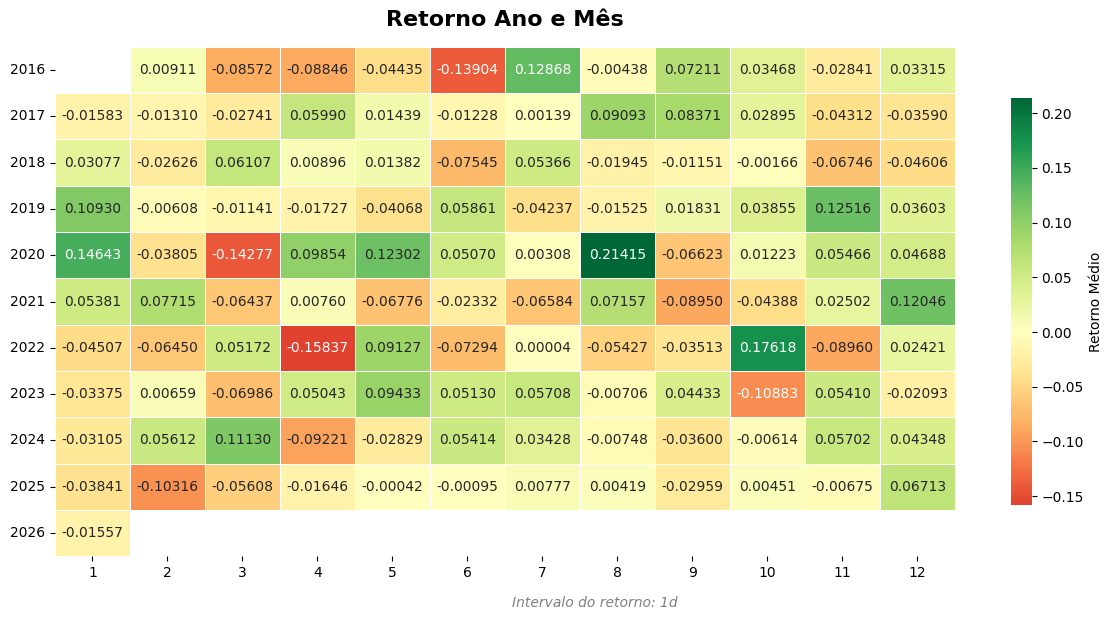

In [71]:
tabela = retorno_mensal_ano(df)

plt.style.use("default")
fig, ax = plt.subplots(figsize=(12, 6))

# Gráfico: Retorno médio
sns.heatmap(
    tabela,
    annot=True,
    fmt=".5f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={
        "shrink": 0.8,
        "label": "Retorno Médio"
    },
    square=False  # deixa os quadrados uniformes
)
ax.set_title("Retorno Ano e Mês", fontsize=16, weight="bold", pad=15)
ax.set_xlabel("")
ax.set_ylabel("")

# Eixo x meses
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0,
    ha="center",
    fontsize=10
)

# Eixo y anos
ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=10
)

# Rodapé
fig.text(
    0.5, -0.02,               # posição x (0.5 = centro), y (abaixo do gráfico)
    f"Intervalo do retorno: {interval}", 
    ha='center',              # centraliza o texto
    fontsize=10,
    color='gray',
    style='italic'
)

plt.tight_layout()
plt.show()


## **7.1**

*Contagem meses negativos por mes*

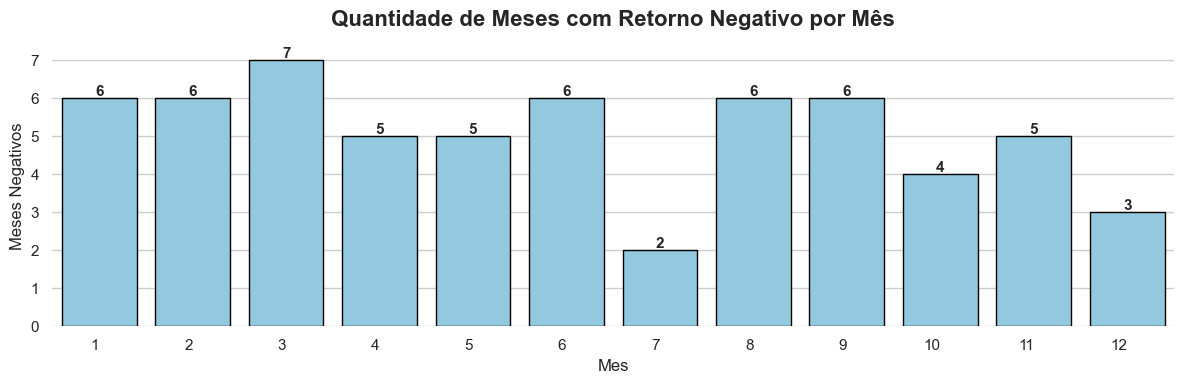

In [72]:
qtd_negativos = (tabela.T < 0).sum(axis=1)

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 4))

sns.barplot(
    x=qtd_negativos.index,
    y=qtd_negativos.values,
    ax=ax,
    color="skyblue",
    edgecolor="black",
)

ax.set_title("Quantidade de Meses com Retorno Negativo por Mês", fontsize=16, weight="bold", pad=15)
ax.set_xlabel("Mes")
ax.set_ylabel("Meses Negativos", fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="right", fontsize=11)

for i, v in enumerate(qtd_negativos.values):
    ax.text(i, v + 0.05, str(v), ha='center', fontsize=11, weight="bold")

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()


---

# **8.0**

*Topos e fundos, retornos, média das máximas e mínimas dos retornos*

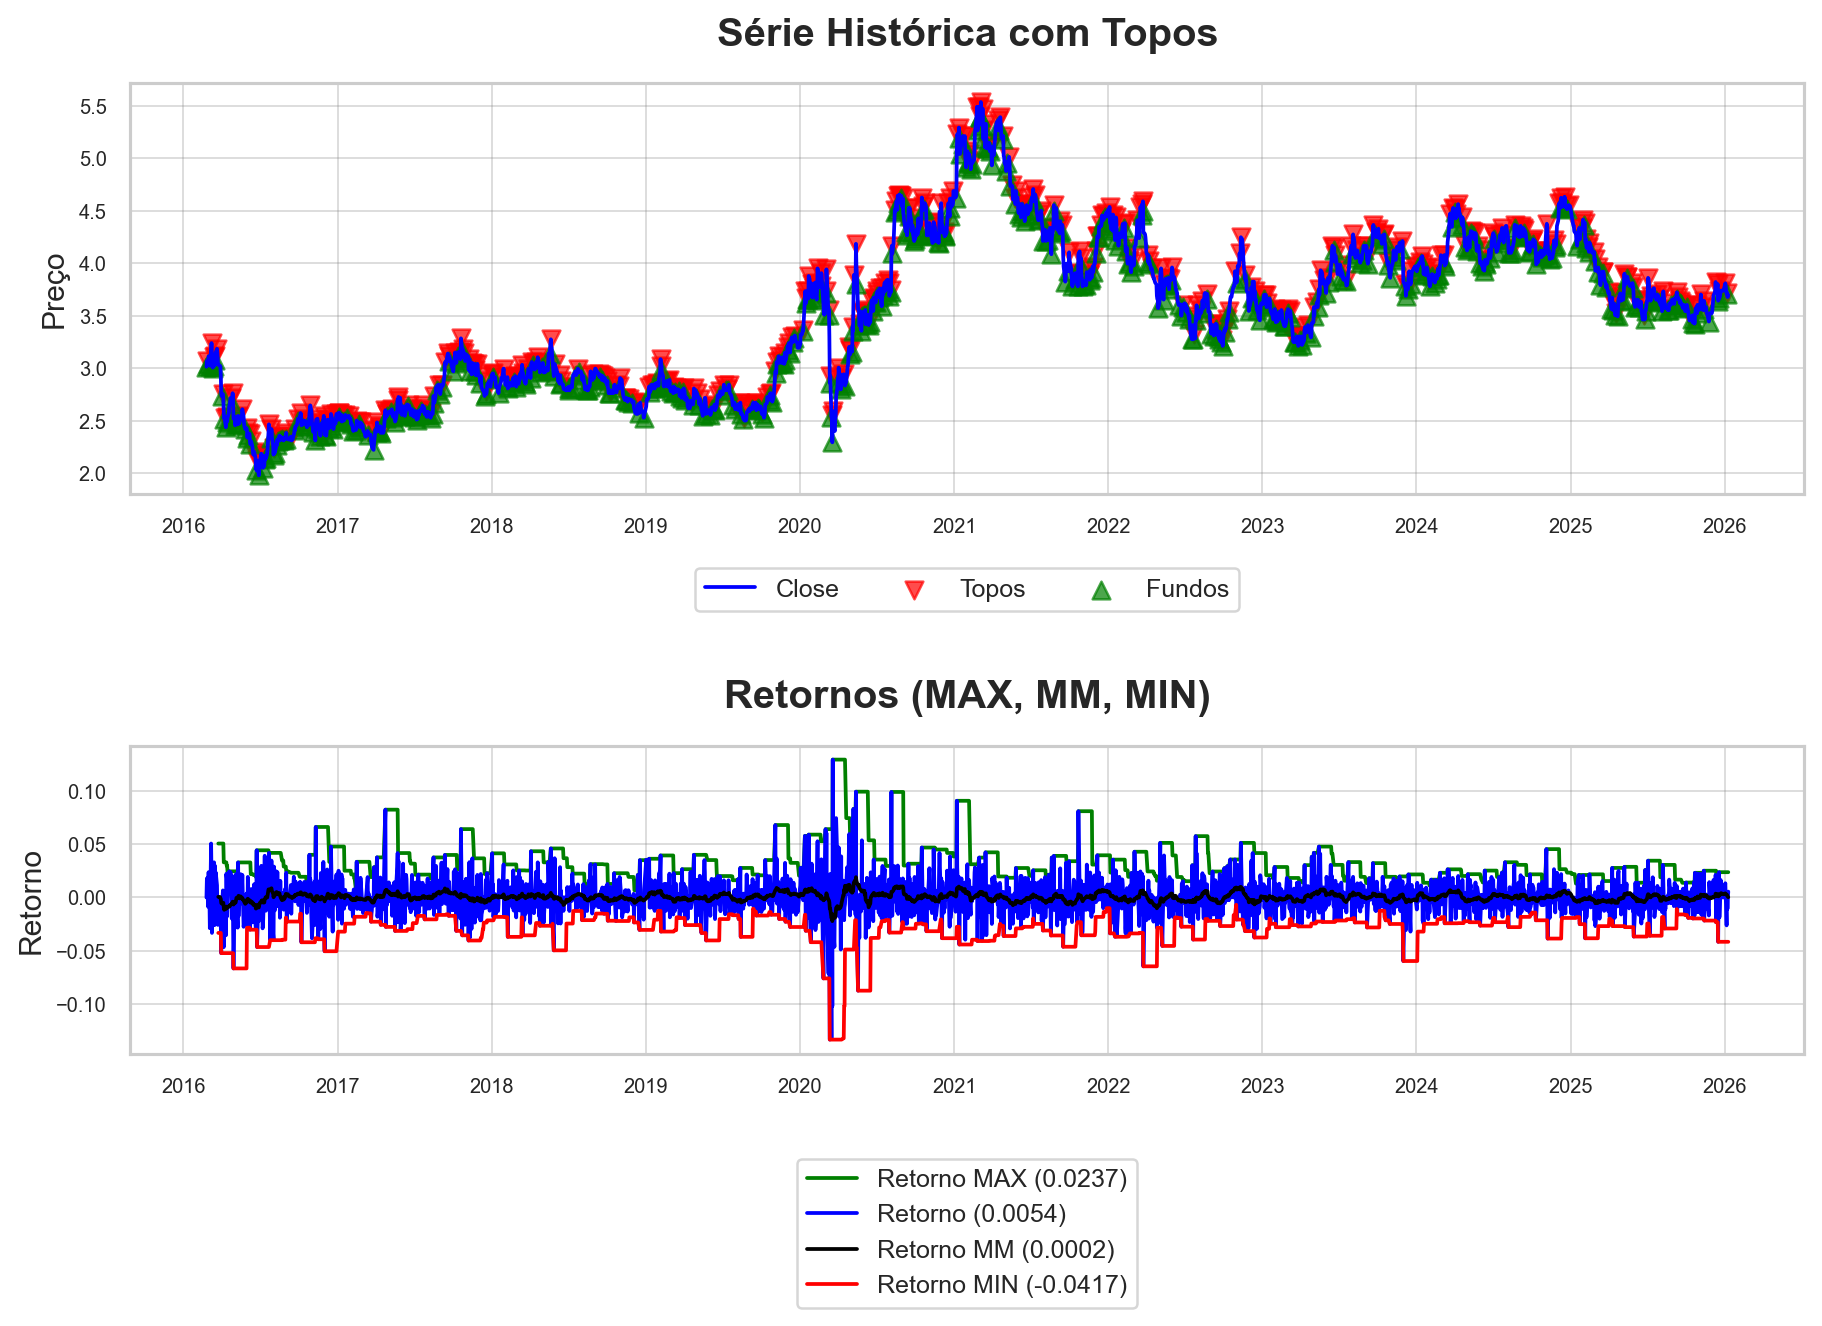

In [73]:
sns.set_theme(style="whitegrid") # Estilo seaborn 
plt.rcParams["figure.dpi"] = 180 # Aumenta a qualidade da imagem

fig, ax = plt.subplots(
    2, 1,
    figsize=(12, 7),
    sharex=False,
    sharey=False,
    gridspec_kw={"height_ratios": [2, 1.5]}
)

ax1 = ax[0]
ax2 = ax[1]

# --- Gráficoico 1: Série histórica com topos e fundos marcados ---

topos, fundos = encontrar_topos_fundos(df['Close'].values)

sns.lineplot(
    ax=ax1,
    x=df.index, 
    y=df['Close'], 
    label='Close', 
    color='blue'
    )

ax1.scatter(df['Close'].index[topos], df['Close'].values[topos], color='red', label='Topos', marker='v', s=50, alpha=0.7)
ax1.scatter(df['Close'].index[fundos], df['Close'].values[fundos], color='green', label='Fundos', marker='^', s=50, alpha=0.7)

ax1.set_title('Série Histórica com Topos', fontsize=16, weight="bold", pad=15)
ax1.set_ylabel('Preço')
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, fontsize=10)

# --- Gráfico 2: Retorno + Média maximas dos retornos + retorno + Média dos retornos + Média minima dos retornos ---

sns.lineplot(
    ax=ax2,
    x=df.index, 
    y=df['media_21_a_max_retorno'], 
    label=f'Retorno MAX ({df.media_21_a_max_retorno.iloc[-1]:.4f})', 
    color='green')

sns.lineplot(
    ax=ax2,
    x=df.index, 
    y=df['retorno'], 
    label=f'Retorno ({df.retorno.iloc[-1]:.4f})', 
    color='blue')

sns.lineplot(
    ax=ax2,
    x=df.index, 
    y=df['media_21_a_mean_retorno'], 
    label=f'Retorno MM ({df.media_21_a_mean_retorno.iloc[-1]:.4f})', 
    color='black')

sns.lineplot(
    ax=ax2,
    x=df.index, 
    y=df['media_21_a_min_retorno'], 
    label=f'Retorno MIN ({df.media_21_a_min_retorno.iloc[-1]:.4f})', 
    color='red')

ax2.set_title('Retornos (MAX, MM, MIN)', fontsize=16, weight="bold", pad=15)
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.30), ncol=1, fontsize=10)
ax2.set_ylabel('Retorno')

for a in [ax1, ax2]:
    a.tick_params(axis='both', labelsize=8)  # tamanho dos números dos eixos
    a.set_xlabel(None)
    a.grid(True, linestyle="-", linewidth=0.7, color="gray", alpha=0.3)


plt.subplots_adjust(hspace=0.70)
plt.show()


In [74]:
df[['media_21_a_max_retorno', 'retorno', 'media_21_a_mean_retorno', 'media_21_a_min_retorno']].tail(3)

Price,media_21_a_max_retorno,retorno,media_21_a_mean_retorno,media_21_a_min_retorno
Date,,,,
2026-01-07,0.023686,-0.010753,0.001264,-0.041667
2026-01-08,0.023686,0.000000,0.000739,-0.041667
2026-01-09,0.023686,0.005435,0.000219,-0.041667
